# Download data and preprocessing

In [10]:
from pathlib import Path
import os
DATA_PATH=Path('./dataset/')
DATA_PATH.mkdir(exist_ok=True)

if not os.path.exists('./dataset/aclImdb'):
    !curl -O http://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz
    !tar -xf aclImdb_v1.tar.gz -C {DATA_PATH}

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 80.2M  100 80.2M    0     0  33.4M      0  0:00:02  0:00:02 --:--:-- 33.4M


In [11]:
import tarfile

file_path = 'aclImdb_v1.tar.gz'
extract_path = './dataset/'

with tarfile.open(file_path, 'r:gz') as tar:
    tar.extractall(path=extract_path)

print(f"File extracted to {extract_path}")

/tmp/ipykernel_4710/2864593206.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


File extracted to ./dataset/


In [12]:
import numpy as np
CLASSES = ['neg', 'pos']#, 'unsup']
PATH=Path('./dataset/aclImdb/')

def get_texts(path):
    texts,labels = [],[]
    for idx,label in enumerate(CLASSES):

        for fname in (path/label).glob('*.*'):
            texts.append(fname.open('r', encoding='utf-8').read())
            labels.append(idx)
    return texts, labels

trn_texts,trn_labels = get_texts(PATH/'train')
tst_texts,tst_labels = get_texts(PATH/'test')

In [13]:
import nltk
from nltk.corpus import stopwords
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')
stop_words = stopwords.words('english')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [14]:
import re
import string
import html
import unicodedata
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

def remove_special_chars(text):
    re1 = re.compile(r'[  ]+')
    x = html.unescape(text)

    x = x.replace(' @.@ ', '.')
    x = x.replace(' @-@ ', '-')
    x = x.replace('\\', ' \\ ')

    return re1.sub(' ', x)


def remove_non_ascii(text):
    """Remove non-ASCII characters from list of tokenized words"""
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')


def to_lowercase(text):
    return text.lower()



def remove_punctuation(text):
    """Remove punctuation from list of tokenized words"""
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)


def replace_numbers(text):
    """Replace all interger occurrences in list of tokenized words with textual representation"""
    return re.sub(r'\d+', '', text)


def remove_whitespaces(text):
    return text.strip()


def remove_stopwords(words, stop_words):
    """
    :param words:
    :type words:
    :param stop_words: from sklearn.feature_extraction.stop_words import ENGLISH_STOP_WORDS
    or
    from spacy.lang.en.stop_words import STOP_WORDS
    :type stop_words:
    :return:
    :rtype:
    """
    return [word for word in words if word not in stop_words]


def stem_words(words):
    """Stem words in text"""
    stemmer = PorterStemmer()
    return [stemmer.stem(word) for word in words]

def lemmatize_words(words):
    """Lemmatize words in text"""

    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in words]

def lemmatize_verbs(words):
    """Lemmatize verbs in text"""

    lemmatizer = WordNetLemmatizer()
    return ' '.join([lemmatizer.lemmatize(word, pos='v') for word in words])

def text2words(text):
  return word_tokenize(text)

def normalize_text( text):
    text = remove_special_chars(text)
    text = remove_non_ascii(text)
    text = remove_punctuation(text)
    text = to_lowercase(text)
    text = replace_numbers(text)
    words = text2words(text)
    words = remove_stopwords(words, stop_words)
    words = lemmatize_words(words)
    words = lemmatize_verbs(words)

    return ''.join(words)

In [15]:
def normalize_corpus(corpus):
  return [normalize_text(t) for t in corpus]
tst_texts = normalize_corpus(tst_texts)
trn_texts = normalize_corpus(trn_texts)

In [16]:
texts = trn_texts + tst_texts

# BoW with keras Tokenizer

## Examples

Doc 1: "good food, good service"

Doc 2: "good food, amazing food"

Doc 3: "bad service, bad food"

Doc 4: "amazing service, fast service"

Doc 5: "the food was amazing"

Vocabulary: ['amazing', 'bad', 'fast', 'food', 'good', 'service', 'the', 'was']

### Binary


|       | amazing | bad | fast | food | good | service | the | was |
|-------|---------|-----|------|------|------|---------|-----|-----|
| Doc 1 |    0    |  0  |  0   |  1   |  1   |    1    |  0  |  0  |
| Doc 2 |    1    |  0  |  0   |  1   |  1   |    0    |  0  |  0  |
| Doc 3 |    0    |  1  |  0   |  1   |  0   |    1    |  0  |  0  |
| Doc 4 |    1    |  0  |  1   |  0   |  0   |    1    |  0  |  0  |
| Doc 5 |    1    |  0  |  0   |  1   |  0   |    0    |  1  |  1  |




### Counts (TF)


|       | amazing | bad | fast | food | good | service | the | was |
|-------|---------|-----|------|------|------|---------|-----|-----|
| Doc 1 |    0    |  0  |  0   |  1   |  2   |    1    |  0  |  0  |
| Doc 2 |    1    |  0  |  0   |  2   |  1   |    0    |  0  |  0  |
| Doc 3 |    0    |  2  |  0   |  1   |  0   |    1    |  0  |  0  |
| Doc 4 |    1    |  0  |  1   |  0   |  0   |    2    |  0  |  0  |
| Doc 5 |    1    |  0  |  0   |  1   |  0   |    0    |  1  |  1  |


### Frequency (Normalized)


|       | amazing | bad | fast | food | good | service | the | was |
|-------|---------|-----|------|------|------|---------|-----|-----|
| Doc 1 |  0.00   | 0.0 | 0.00 | 0.25 | 0.50 |  0.25   | 0.00 | 0.00 |
| Doc 2 |  0.25   | 0.0 | 0.00 | 0.50 | 0.25 |  0.00   | 0.00 | 0.00 |
| Doc 3 |  0.00   | 0.5 | 0.00 | 0.25 | 0.00 |  0.25   | 0.00 | 0.00 |
| Doc 4 |  0.25   | 0.0 | 0.25 | 0.00 | 0.00 |  0.50   | 0.00 | 0.00 |
| Doc 5 |  0.25   | 0.0 | 0.00 | 0.25 | 0.00 |  0.00   | 0.25 | 0.25 |


### TF-IDF


|       | amazing | bad | fast | food | good | service | the | was |
|-------|---------|-----|------|------|------|---------|-----|-----|
| Doc 1 |  0.00   | 0.00 | 0.00 | 0.31 | 0.88 |  0.36  | 0.0 | 0.0 |
| Doc 2 |  0.44   | 0.00 | 0.00 | 0.73 | 0.52 |  0.00  | 0.0 | 0.0 |
| Doc 3 |  0.00   | 0.92 | 0.00 | 0.26 | 0.00 |  0.31  | 0.0 | 0.0 |
| Doc 4 |  0.37   | 0.00 | 0.56 | 0.00 | 0.00 |  0.74  | 0.0 | 0.0 |
| Doc 5 |  0.40   | 0.00 | 0.00 | 0.34 | 0.00 |  0.00  | 0.6 | 0.6 |

In [17]:
from tensorflow.keras.preprocessing.text import Tokenizer

tok = Tokenizer(oov_token='UNK')
tok.fit_on_texts(texts)
bow = tok.texts_to_matrix(texts[:10], mode='binary')
bow.shape

(10, 154720)

In [18]:
bow

array([[0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.]])

In [19]:

tok = Tokenizer(num_words=100, oov_token='UNK')
tok.fit_on_texts(texts)
bow = tok.texts_to_matrix(texts[:10], mode='binary')
bow.shape

(10, 100)

In [20]:
texts[0]

'film secret government mind experiment corrupt use citizenry secretive vile shadowy figure potential really interest movie fail wont elaborate much rather confuse plot line look detail explanation comment user reluctantpopstar give good description itbr br didnt work find slow would okay fact seem go nowhere viewer leave dark many thing really able get handle moviein film one argue filmmaker intend provoke think leave thing ambiguous reason dont think case herebr br frequent long shoot two build frequently mention usersi see pointthey give viewer time get another drink without miss action suspect many viewer would welcome opportunity several beverage board get one'

In [21]:
bow

array([[0., 1., 1., 1., 1., 1., 0., 0., 1., 1., 1., 1., 0., 0., 1., 0.,
        1., 0., 1., 1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 0., 0., 0.,
        1., 0., 0., 1., 0., 0., 0., 0., 0., 1., 1., 0., 0., 1., 1., 1.,
        0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 1., 1., 1., 1., 0., 1., 1., 1., 0., 0., 1., 0., 1., 1., 1.,
        1., 0., 0., 1., 0., 0., 0., 1., 1., 0., 0., 0., 1., 0., 0., 0.,
        0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0., 0., 0., 0.,
        0., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.,
        0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
        0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0.],
       [0., 1., 0., 1., 1., 0., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1.,
        0., 0.

## Binary

In [22]:
vocab_sz = 10000 # None means all
tok = Tokenizer(num_words=vocab_sz, oov_token='UNK')
#tok = Tokenizer(oov_token='UNK')
tok.fit_on_texts(trn_texts + tst_texts)
#vocab_sz = len(tok.word_index) # If all possible vocab, else, it's the predefine vocab_sz. Remember we cannot always use the len(tok.word_index), since it's always the max.

# Extract binary BoW features
x_train = tok.texts_to_matrix(trn_texts, mode='binary')
x_test = tok.texts_to_matrix(tst_texts, mode='binary')

In [23]:
y_train = np.asarray(trn_labels).astype('float32')
y_test = np.asarray(tst_labels).astype('float32')

print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(25000, 10000)
(25000,)
(25000, 10000)
(25000,)


### Model

In [24]:
from keras import models
from keras import layers

model = models.Sequential()



model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
from keras import losses
from keras import metrics
from keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

In [26]:
# x_val = x_train[:10000]
# partial_x_train = x_train[10000:]

# y_val = y_train[:10000]
# partial_y_train = y_train[10000:]

In [27]:
history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=128,
                    validation_data=(x_test, y_test))

Epoch 1/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 9s 39ms/step - binary_accuracy: 0.8514 - loss: 0.3722 - val_binary_accuracy: 0.8742 - val_loss: 0.3087
Epoch 2/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - binary_accuracy: 0.9125 - loss: 0.2281 - val_binary_accuracy: 0.8741 - val_loss: 0.3131
Epoch 3/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - binary_accuracy: 0.9302 - loss: 0.1858 - val_binary_accuracy: 0.8705 - val_loss: 0.3337
Epoch 4/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - binary_accuracy: 0.9441 - loss: 0.1551 - val_binary_accuracy: 0.8650 - val_loss: 0.3720
Epoch 5/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - binary_accuracy: 0.9534 - loss: 0.1293 - val_binary_accuracy: 0.8526 - val_loss: 0.4433
Epoch 6/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - binary_accuracy: 0.9626 - loss: 0.1071 - val_binary_accuracy: 0.8568 - val_loss: 0.4515
Epoch 7/20
196/196 ━━━━━━━━━━━━━━━━━━━━ 4s 21ms/step - binary_accuracy: 0.9709 - loss: 0.0862 - val_binary_accuracy: 0.8528 - val_loss: 0.5075

In [28]:
import matplotlib.pyplot as plt

history_dict = history.history
history_dict

{'binary_accuracy': [0.851360023021698,
  0.9124799966812134,
  0.9301599860191345,
  0.9441199898719788,
  0.9533600211143494,
  0.9625999927520752,
  0.9709200263023376,
  0.9789599776268005,
  0.9832800030708313,
  0.9886800050735474,
  0.9925199747085571,
  0.9948800206184387,
  0.9964399933815002,
  0.9976800084114075,
  0.9986000061035156,
  0.9991199970245361,
  0.999239981174469,
  0.9995599985122681,
  0.9997599720954895,
  0.9998800158500671],
 'loss': [0.3722268044948578,
  0.22807660698890686,
  0.1857568919658661,
  0.1551087498664856,
  0.12934266030788422,
  0.10705361515283585,
  0.08620008081197739,
  0.06711432337760925,
  0.051416393369436264,
  0.03843056410551071,
  0.027855483815073967,
  0.019790997728705406,
  0.014368305914103985,
  0.009505270048975945,
  0.006157339084893465,
  0.004080943763256073,
  0.002855794969946146,
  0.0016914720181375742,
  0.0008435829658992589,
  0.0004716737603303045],
 'val_binary_accuracy': [0.8741599917411804,
  0.8741199970245

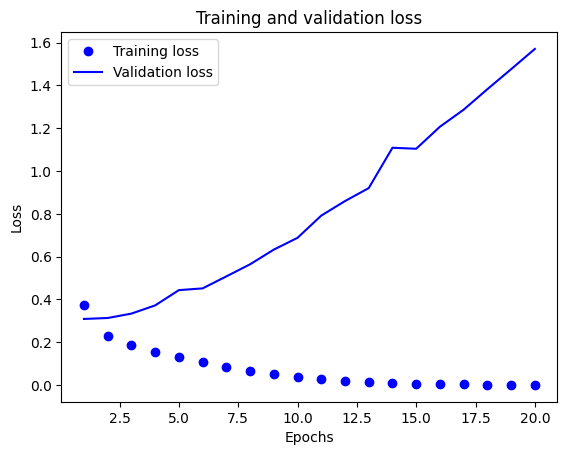

In [29]:
import matplotlib.pyplot as plt

history_dict = history.history
history_dict.keys()


acc = history.history['binary_accuracy']
val_acc = history.history['val_binary_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(acc) + 1)

# "bo" is for "blue dot"
plt.plot(epochs, loss, 'bo', label='Training loss')
# b is for "solid blue line"
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

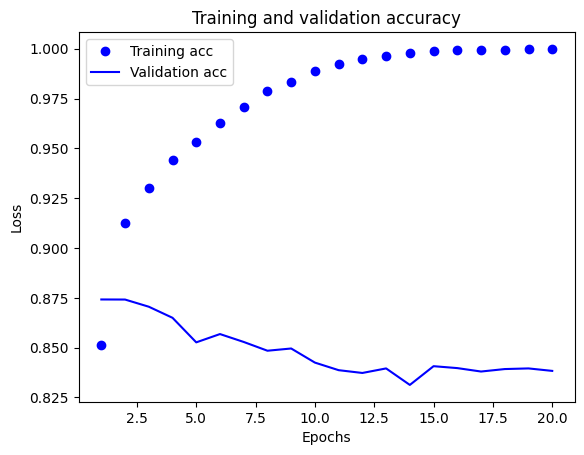

In [30]:
plt.clf()   # clear figure
acc_values = history_dict['binary_accuracy']
val_acc_values = history_dict['val_binary_accuracy']

plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()


---

In [31]:
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from sklearn.utils import shuffle

trn_texts,trn_labels = get_texts(PATH/'train')
tst_texts,tst_labels = get_texts(PATH/'test')

trn_texts = normalize_corpus(trn_texts)
tst_texts = normalize_corpus(tst_texts)

vocab_sz = 10000
tok = Tokenizer(num_words=vocab_sz, oov_token='UNK')
tok.fit_on_texts(trn_texts + tst_texts)

# Extract binary BoW features
x_train = tok.texts_to_matrix(trn_texts, mode='binary')
x_test = tok.texts_to_matrix(tst_texts, mode='binary')

y_train = np.asarray(trn_labels).astype('float32')
y_test = np.asarray(tst_labels).astype('float32')

# Shuffle the training data
x_train, y_train = shuffle(x_train, y_train, random_state=42)
x_test, y_test = shuffle(x_test, y_test, random_state=42)

In [32]:
from keras import models
from keras import layers

model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │       160,016 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 160,305 (626.19 KB)

 Trainable params: 160,305 (626.19 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
from keras import losses
from keras import metrics
from keras import optimizers

model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

history = model.fit(x_train,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_test, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 7s 118ms/step - binary_accuracy: 0.8291 - loss: 0.4544 - val_binary_accuracy: 0.8733 - val_loss: 0.3433
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 38ms/step - binary_accuracy: 0.9014 - loss: 0.2723 - val_binary_accuracy: 0.8788 - val_loss: 0.3018
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 3s 55ms/step - binary_accuracy: 0.9193 - loss: 0.2194 - val_binary_accuracy: 0.8766 - val_loss: 0.3031
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - binary_accuracy: 0.9321 - loss: 0.1862 - val_binary_accuracy: 0.8730 - val_loss: 0.3139
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 68ms/step - binary_accuracy: 0.9416 - loss: 0.1647 - val_binary_accuracy: 0.8678 - val_loss: 0.3399
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - binary_accuracy: 0.9484 - loss: 0.1467 - val_binary_accuracy: 0.8584 - val_loss: 0.3810
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - binary_accuracy: 0.9557 - loss: 0.1313 - val_binary_accuracy: 0.8550 - val_loss: 0.4068
Epoch 8/20
4

## Text Embedding Model

Instead of Bag-of-Words, we can represent each word as a dense vector (an embedding). Keras provides an `Embedding` layer that can learn these embeddings. First, we need to convert our texts into sequences of integers (where each integer represents a word's index in the vocabulary) and then pad these sequences so they all have the same length.

In [34]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Convert texts to sequences of word indices
x_train_sequences = tok.texts_to_sequences(trn_texts)
x_test_sequences = tok.texts_to_sequences(tst_texts)

# Determine maximum sequence length for padding
maxlen = max([len(x) for x in x_train_sequences + x_test_sequences])
print(f"Maximum sequence length: {maxlen}")

# Pad sequences to ensure uniform input length for the embedding layer
x_train_padded = pad_sequences(x_train_sequences, maxlen=maxlen)
x_test_padded = pad_sequences(x_test_sequences, maxlen=maxlen)

print(f"Shape of padded training data: {x_train_padded.shape}")
print(f"Shape of padded test data: {x_test_padded.shape}")

Maximum sequence length: 1440
Shape of padded training data: (25000, 1440)
Shape of padded test data: (25000, 1440)


Now, let's define a new model that incorporates an `Embedding` layer. This layer takes the integer-encoded input, looks up the embedding vector for each word index, and effectively converts the positive integers into dense vectors of a fixed size (e.g., 16, 32, or 128 dimensions).

In [35]:
from keras import models
from keras import layers

# Define the embedding dimension
embedding_dim = 16

embedding_model = models.Sequential()
# The Embedding layer takes as input:
# 1. vocabulary size (vocab_sz)
# 2. embedding dimension (embedding_dim)
# 3. input length (maxlen, the length of sequences after padding)
embedding_model.add(layers.Embedding(input_dim=vocab_sz, output_dim=embedding_dim, input_length=maxlen))
# After the embedding layer, we flatten the output for a dense layer
# Alternatively, a GlobalAveragePooling1D layer can be used to average embeddings per sequence
embedding_model.add(layers.Flatten())
embedding_model.add(layers.Dense(16, activation='relu'))
embedding_model.add(layers.Dense(16, activation='relu'))
embedding_model.add(layers.Dense(1, activation='sigmoid'))

embedding_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Next, compile and train this new model using the padded sequences. This process is similar to what you did with the Bag-of-Words model.

In [36]:
from keras import losses
from keras import metrics
from keras import optimizers

embedding_model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
              loss=losses.binary_crossentropy,
              metrics=[metrics.binary_accuracy])

history_embedding = embedding_model.fit(x_train_padded,
                    y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_test_padded, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 427ms/step - binary_accuracy: 0.4988 - loss: 0.6933 - val_binary_accuracy: 0.4991 - val_loss: 0.6931
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 390ms/step - binary_accuracy: 0.4978 - loss: 0.6932 - val_binary_accuracy: 0.5008 - val_loss: 0.6932
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 24s 483ms/step - binary_accuracy: 0.4960 - loss: 0.6932 - val_binary_accuracy: 0.4996 - val_loss: 0.6932
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 21s 424ms/step - binary_accuracy: 0.5081 - loss: 0.6931 - val_binary_accuracy: 0.5013 - val_loss: 0.6932
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 505ms/step - binary_accuracy: 0.5435 - loss: 0.6920 - val_binary_accuracy: 0.4982 - val_loss: 0.6932
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 19s 395ms/step - binary_accuracy: 0.5832 - loss: 0.6873 - val_binary_accuracy: 0.4998 - val_loss: 0.6937
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 22s 418ms/step - binary_accuracy: 0.5418 - loss: 0.6962 - val_binary_accuracy: 0.5000 - val_loss: 0.6967

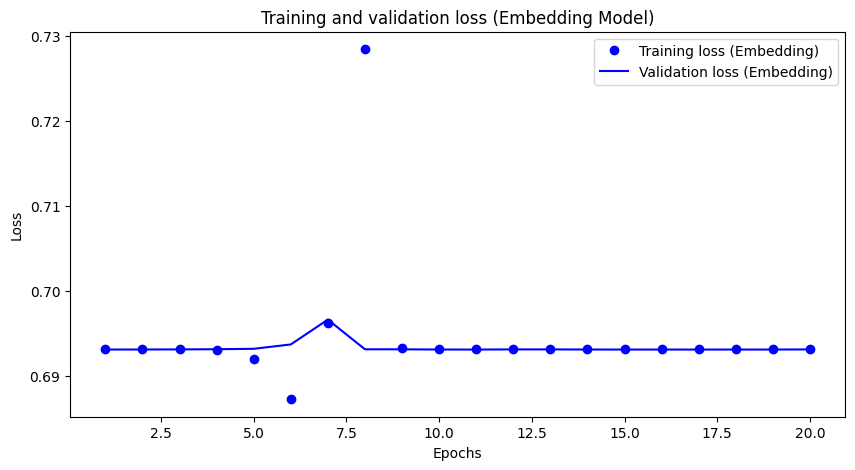

In [37]:
import matplotlib.pyplot as plt

history_embedding_dict = history_embedding.history
history_embedding_dict.keys()

acc_embedding = history_embedding_dict['binary_accuracy']
val_acc_embedding = history_embedding_dict['val_binary_accuracy']
loss_embedding = history_embedding_dict['loss']
val_loss_embedding = history_embedding_dict['val_loss']

epochs = range(1, len(acc_embedding) + 1)

# Plotting training and validation loss for the embedding model
plt.figure(figsize=(10, 5))
plt.plot(epochs, loss_embedding, 'bo', label='Training loss (Embedding)')
plt.plot(epochs, val_loss_embedding, 'b', label='Validation loss (Embedding)')
plt.title('Training and validation loss (Embedding Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

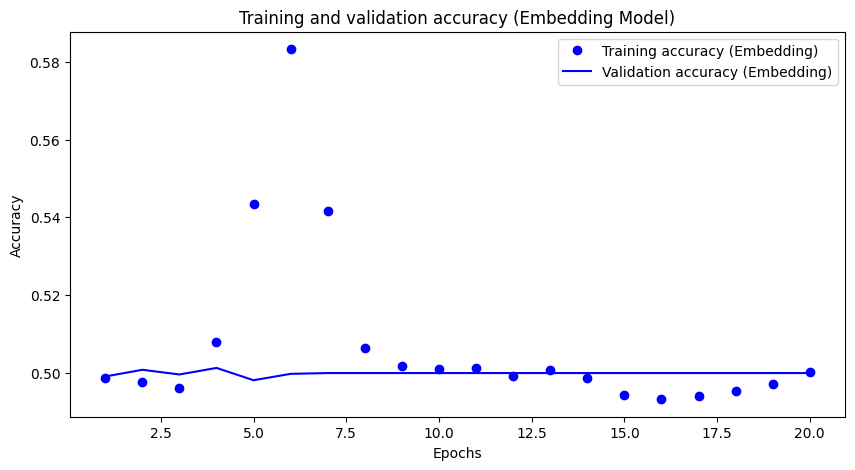

In [38]:
plt.clf()   # clear figure

# Plotting training and validation accuracy for the embedding model
plt.figure(figsize=(10, 5))
plt.plot(epochs, acc_embedding, 'bo', label='Training accuracy (Embedding)')
plt.plot(epochs, val_acc_embedding, 'b', label='Validation accuracy (Embedding)')
plt.title('Training and validation accuracy (Embedding Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

---

## Word2Vec Embedding Model

For Word2Vec, we typically need the text to be in a list of lists of words format. Since our `normalize_text` function currently returns a single string, we'll re-tokenize the normalized texts into lists of words.

In [42]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 14.0 MB/s eta 0:00:00


In [43]:
# Re-running data preparation steps to ensure all variables are defined for Word2Vec
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.utils import shuffle
from pathlib import Path

# Ensure PATH, CLASSES, get_texts, normalize_corpus, normalize_text are defined or re-defined if kernel was reset
# (Assuming these are defined in earlier cells, this section re-runs them for robustness)

# Define PATH and CLASSES again for robustness if kernel state was lost
CLASSES = ['neg', 'pos']
PATH=Path('./dataset/aclImdb/')

# Redefine get_texts, normalize_text, normalize_corpus for robustness
def get_texts(path):
    texts,labels = [],[]
    for idx,label in enumerate(CLASSES):

        for fname in (path/label).glob('*.*'):
            texts.append(fname.open('r', encoding='utf-8').read())
            labels.append(idx)
    return texts, labels

# Assuming these are defined in earlier cells (eG42nZHo3cL_)
import re
import string
import html
import unicodedata
from nltk.tokenize import word_tokenize # Already imported, but good to ensure
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

stop_words = stopwords.words('english') # Ensure stop_words is defined

def remove_special_chars(text):
    re1 = re.compile(r'[  ]+')
    x = html.unescape(text)

    x = x.replace(' @.@ ', '.')
    x = x.replace(' @-@ ', '-')
    x = x.replace('\\', ' \\ ')

    return re1.sub(' ', x)

def remove_non_ascii(text):
    return unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('utf-8', 'ignore')

def to_lowercase(text):
    return text.lower()

def remove_punctuation(text):
    translator = str.maketrans('', '', string.punctuation)
    return text.translate(translator)

def replace_numbers(text):
    return re.sub(r'\d+', '', text)

def remove_whitespaces(text):
    return text.strip()

def remove_stopwords(words, stop_words):
    return [word for word in words if word not in stop_words]

def lemmatize_words(words):
    lemmatizer = WordNetLemmatizer()
    return [lemmatizer.lemmatize(word) for word in words]

def lemmatize_verbs(words):
    lemmatizer = WordNetLemmatizer()
    return ' '.join([lemmatizer.lemmatize(word, pos='v') for word in words])

def text2words(text):
  return word_tokenize(text)

def normalize_text(text):
    text = remove_special_chars(text)
    text = remove_non_ascii(text)
    text = remove_punctuation(text)
    text = to_lowercase(text)
    text = replace_numbers(text)
    words = text2words(text)
    words = remove_stopwords(words, stop_words)
    words = lemmatize_words(words)
    words = lemmatize_verbs(words)
    return ''.join(words)

def normalize_corpus(corpus):
  return [normalize_text(t) for t in corpus]


# Re-load and normalize texts
trn_texts, trn_labels = get_texts(PATH/'train')
tst_texts, tst_labels = get_texts(PATH/'test')

trn_texts = normalize_corpus(trn_texts)
tst_texts = normalize_corpus(tst_texts)

vocab_sz = 10000 # Define vocab_sz
tok = Tokenizer(num_words=vocab_sz, oov_token='UNK')
tok.fit_on_texts(trn_texts + tst_texts)

# Convert texts to sequences of word indices
x_train_sequences = tok.texts_to_sequences(trn_texts)
x_test_sequences = tok.texts_to_sequences(tst_texts)

# Determine maximum sequence length for padding
maxlen = max([len(x) for x in x_train_sequences + x_test_sequences])
print(f"Maximum sequence length: {maxlen}")

# Pad sequences
x_train_padded = pad_sequences(x_train_sequences, maxlen=maxlen)
x_test_padded = pad_sequences(x_test_sequences, maxlen=maxlen)

y_train = np.asarray(trn_labels).astype('float32')
y_test = np.asarray(tst_labels).astype('float32')

# Shuffle data
x_train_padded, y_train = shuffle(x_train_padded, y_train, random_state=42)
x_test_padded, y_test = shuffle(x_test_padded, y_test, random_state=42)

print(f"Shape of x_train_padded: {x_train_padded.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of x_test_padded: {x_test_padded.shape}")
print(f"Shape of y_test: {y_test.shape}")

Maximum sequence length: 1440
Shape of x_train_padded: (25000, 1440)
Shape of y_train: (25000,)
Shape of x_test_padded: (25000, 1440)
Shape of y_test: (25000,)


In [44]:
from nltk.tokenize import word_tokenize # Already imported, but good to ensure

def get_tokenized_texts(texts):
    return [word_tokenize(text) for text in texts]

# Assuming trn_texts and tst_texts are already normalized (as performed earlier)
trn_texts_tokenized = get_tokenized_texts(trn_texts)
tst_texts_tokenized = get_tokenized_texts(tst_texts)

# Combine for training Word2Vec
all_tokenized_texts = trn_texts_tokenized + tst_texts_tokenized

print(f"First 5 words of first training text: {trn_texts_tokenized[0][:5]}")

First 5 words of first training text: ['film', 'secret', 'government', 'mind', 'experiment']


Now, let's train a Word2Vec model using the `gensim` library. We'll specify the embedding dimension (e.g., 100), the window size, and the minimum word count.

In [45]:
from gensim.models import Word2Vec

# Define Word2Vec parameters
w2v_embedding_dim = 100
min_word_count = 5
window_size = 5

# Train the Word2Vec model
w2v_model = Word2Vec(sentences=all_tokenized_texts,
                     vector_size=w2v_embedding_dim,
                     window=window_size,
                     min_count=min_word_count,
                     workers=4)

print(f"Word2Vec model trained. Vocabulary size: {len(w2v_model.wv)}")
print(f"Example embedding for 'good': {w2v_model.wv['good'][:5]}...") # Show first 5 dimensions

Word2Vec model trained. Vocabulary size: 34689
Example embedding for 'good': [-1.0095592 -3.089241  -2.8294952  0.7009458  1.2928851]...


Next, we need to create an embedding matrix that Keras can use. This matrix will map each word in our `tok` (Tokenizer) vocabulary to its corresponding Word2Vec vector. Words not found in the Word2Vec model will be initialized with zeros.

In [46]:
import numpy as np

# Initialize embedding matrix with zeros
embedding_matrix = np.zeros((vocab_sz, w2v_embedding_dim))

# Fill the embedding matrix with Word2Vec vectors
# vocab_sz comes from the Keras Tokenizer used earlier
for word, i in tok.word_index.items():
    if i < vocab_sz:
        if word in w2v_model.wv:
            embedding_matrix[i] = w2v_model.wv[word]
        else:
            # Optional: initialize out-of-vocabulary words with random vectors
            # For now, we leave them as zeros
            pass

print(f"Shape of embedding matrix: {embedding_matrix.shape}")

Shape of embedding matrix: (10000, 100)


Now, we can build a new Keras model using this pre-trained `embedding_matrix` in the `Embedding` layer. We'll set `trainable=False` for the embedding layer, meaning the pre-trained weights won't be updated during training (you can set it to `True` for fine-tuning).

In [47]:
from keras import models
from keras import layers

w2v_keras_model = models.Sequential()
w2v_keras_model.add(layers.Embedding(input_dim=vocab_sz,
                                     output_dim=w2v_embedding_dim,
                                     weights=[embedding_matrix],
                                     input_length=maxlen,
                                     trainable=False))

w2v_keras_model.add(layers.Flatten())
w2v_keras_model.add(layers.Dense(16, activation='relu'))
w2v_keras_model.add(layers.Dense(16, activation='relu'))
w2v_keras_model.add(layers.Dense(1, activation='sigmoid'))

w2v_keras_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

Finally, compile and train this Word2Vec-based Keras model using the padded sequences. We'll use the same compilation and training parameters as before.

In [48]:
from keras import losses
from keras import metrics
from keras import optimizers

w2v_keras_model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
                        loss=losses.binary_crossentropy,
                        metrics=[metrics.binary_accuracy])

history_w2v = w2v_keras_model.fit(x_train_padded,
                                  y_train,
                                  epochs=20,
                                  batch_size=512,
                                  validation_data=(x_test_padded, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 38s 744ms/step - binary_accuracy: 0.7094 - loss: 0.5728 - val_binary_accuracy: 0.6896 - val_loss: 0.6056
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 31s 642ms/step - binary_accuracy: 0.8222 - loss: 0.3967 - val_binary_accuracy: 0.8068 - val_loss: 0.4264
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 848ms/step - binary_accuracy: 0.8684 - loss: 0.3097 - val_binary_accuracy: 0.7872 - val_loss: 0.4662
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 717ms/step - binary_accuracy: 0.8985 - loss: 0.2454 - val_binary_accuracy: 0.7986 - val_loss: 0.4733
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 39s 797ms/step - binary_accuracy: 0.9224 - loss: 0.1951 - val_binary_accuracy: 0.7641 - val_loss: 0.5808
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 48s 934ms/step - binary_accuracy: 0.9401 - loss: 0.1570 - val_binary_accuracy: 0.7972 - val_loss: 0.5231
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 36s 736ms/step - binary_accuracy: 0.9560 - loss: 0.1220 - val_binary_accuracy: 0.7930 - val_loss: 0.5677

Let's visualize the training and validation metrics for the Word2Vec embedding model.

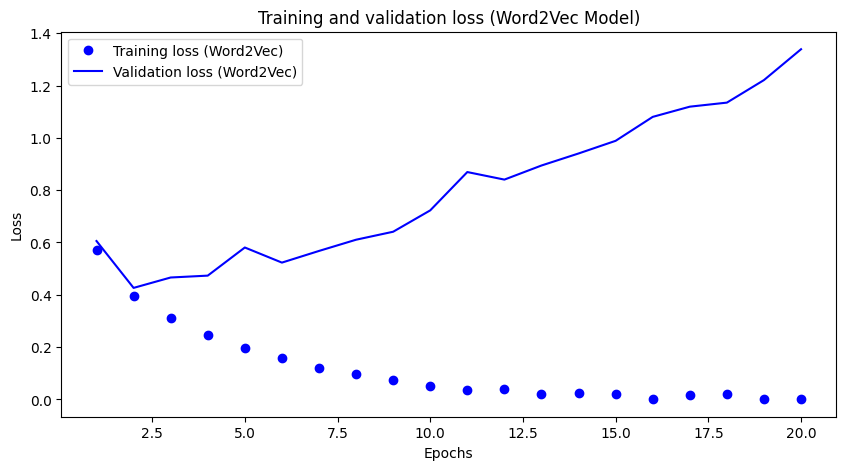

In [49]:
import matplotlib.pyplot as plt

history_w2v_dict = history_w2v.history

acc_w2v = history_w2v_dict['binary_accuracy']
val_acc_w2v = history_w2v_dict['val_binary_accuracy']
loss_w2v = history_w2v_dict['loss']
val_loss_w2v = history_w2v_dict['val_loss']

epochs = range(1, len(acc_w2v) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss_w2v, 'bo', label='Training loss (Word2Vec)')
plt.plot(epochs, val_loss_w2v, 'b', label='Validation loss (Word2Vec)')
plt.title('Training and validation loss (Word2Vec Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

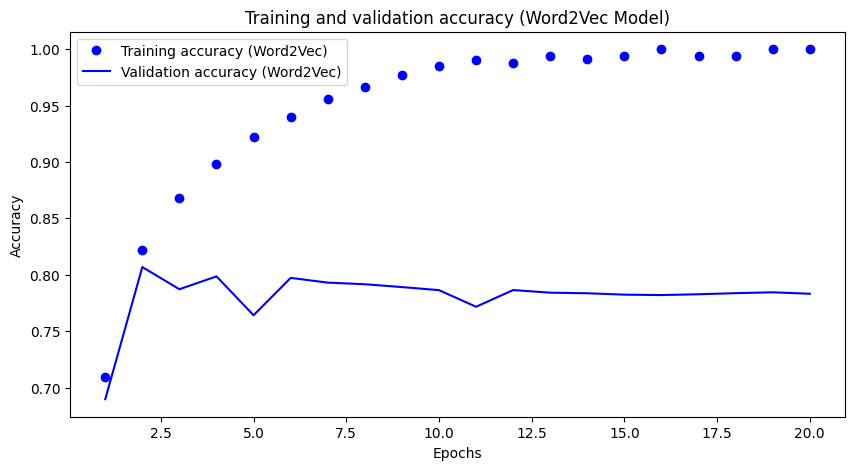

In [61]:
plt.clf()   # clear figure

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc_w2v, 'bo', label='Training accuracy (Word2Vec)')
plt.plot(epochs, val_acc_w2v, 'b', label='Validation accuracy (Word2Vec)')
plt.title('Training and validation accuracy (Word2Vec Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## GloVe Embedding Model

GloVe (Global Vectors for Word Representation) is another popular pre-trained word embedding. It's an unsupervised learning algorithm for obtaining vector representations for words. We'll download pre-trained GloVe vectors, create an embedding matrix, and then use it in a Keras model, similar to how we used Word2Vec.

### Download Pre-trained GloVe Embeddings

We will download the `glove.6B.100d.txt` file, which contains 100-dimensional embeddings trained on 6 billion tokens from Wikipedia and Gigaword. This file is quite large (around 347 MB), so the download might take a moment.

In [52]:
import os

glove_file = 'glove.6B.100d.txt'
glove_url = 'http://nlp.stanford.edu/data/glove.6B.zip'

# Check if the GloVe file already exists or if the zip needs to be downloaded and extracted
if not os.path.exists(glove_file):
    if not os.path.exists('glove.6B.zip'):
        print("Downloading GloVe embeddings (this may take a few minutes)...")
        !wget {glove_url}

    print("Extracting GloVe embeddings...")
    !unzip -q glove.6B.zip
    print("GloVe embeddings extracted.")
else:
    print(f"{glove_file} already exists.")

--2026-05-16 08:19:27--  http://nlp.stanford.edu/data/glove.6B.zip
Resolving nlp.stanford.edu (nlp.stanford.edu)... 171.64.67.140
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:80... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://nlp.stanford.edu/data/glove.6B.zip [following]
--2026-05-16 08:19:27--  https://nlp.stanford.edu/data/glove.6B.zip
Connecting to nlp.stanford.edu (nlp.stanford.edu)|171.64.67.140|:443... connected.
HTTP request sent, awaiting response... 301 Moved Permanently
Location: https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip [following]
--2026-05-16 08:19:27--  https://downloads.cs.stanford.edu/nlp/data/glove.6B.zip
Resolving downloads.cs.stanford.edu (downloads.cs.stanford.edu)... 171.64.64.22
Connecting to downloads.cs.stanford.edu (downloads.cs.stanford.edu)|171.64.64.22|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 862182613 (822M) [application/zip]
Saving to: ‘glove.6B.zip’

glov

### Load GloVe Embeddings

Now, we'll parse the downloaded GloVe file to create a dictionary mapping words to their corresponding embedding vectors. This dictionary will be used to build our embedding matrix for the Keras model.

In [53]:
embeddings_index = {}
with open(glove_file, 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embeddings_index[word] = coefs

print(f"Found {len(embeddings_index)} word vectors.")
print(f"Example embedding for 'good': {embeddings_index.get('good')[:5]}...") # Show first 5 dimensions

Found 400000 word vectors.
Example embedding for 'good': [-0.030769  0.11993   0.53909  -0.43696  -0.73937 ]...


### Create GloVe Embedding Matrix

Similar to the Word2Vec model, we will create an embedding matrix that Keras can use. This matrix will contain the GloVe vectors for words present in our vocabulary (`tok.word_index`). Words not found in GloVe will be initialized with zeros.

In [54]:
glove_embedding_dim = 100 # Match the dimension of the downloaded GloVe vectors

embedding_matrix_glove = np.zeros((vocab_sz, glove_embedding_dim))

for word, i in tok.word_index.items():
    if i < vocab_sz:
        embedding_vector = embeddings_index.get(word)
        if embedding_vector is not None:
            # Words not found in embedding index will be all-zeros.
            embedding_matrix_glove[i] = embedding_vector

print(f"Shape of GloVe embedding matrix: {embedding_matrix_glove.shape}")

Shape of GloVe embedding matrix: (10000, 100)


### Build and Train Keras Model with GloVe Embeddings

Now, let's build a new Keras model. We'll use the `Embedding` layer initialized with `embedding_matrix_glove` and set `trainable=False` to use the pre-trained static embeddings. The rest of the model architecture will be similar to our previous models.

In [55]:
from keras import models
from keras import layers

glove_keras_model = models.Sequential()
glove_keras_model.add(layers.Embedding(input_dim=vocab_sz,
                                     output_dim=glove_embedding_dim,
                                     weights=[embedding_matrix_glove],
                                     input_length=maxlen,
                                     trainable=False)) # Set trainable=False for static embeddings

glove_keras_model.add(layers.Flatten())
glove_keras_model.add(layers.Dense(16, activation='relu'))
glove_keras_model.add(layers.Dense(16, activation='relu'))
glove_keras_model.add(layers.Dense(1, activation='sigmoid'))

glove_keras_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,000,000 (3.81 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,000,000 (3.81 MB)

### Compile and Train GloVe Keras Model

Finally, we compile and train the GloVe-based Keras model using the padded sequences. We'll use the same compilation and training parameters as the other models for fair comparison.

In [56]:
from keras import losses
from keras import metrics
from keras import optimizers

glove_keras_model.compile(optimizer=optimizers.RMSprop(learning_rate=0.001),
                          loss=losses.binary_crossentropy,
                          metrics=[metrics.binary_accuracy])

history_glove = glove_keras_model.fit(x_train_padded,
                                    y_train,
                                    epochs=20,
                                    batch_size=512,
                                    validation_data=(x_test_padded, y_test))

Epoch 1/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 892ms/step - binary_accuracy: 0.6319 - loss: 0.6423 - val_binary_accuracy: 0.7081 - val_loss: 0.5781
Epoch 2/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 710ms/step - binary_accuracy: 0.7390 - loss: 0.5316 - val_binary_accuracy: 0.7456 - val_loss: 0.5233
Epoch 3/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 50s 914ms/step - binary_accuracy: 0.7800 - loss: 0.4688 - val_binary_accuracy: 0.7447 - val_loss: 0.5224
Epoch 4/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 41s 856ms/step - binary_accuracy: 0.8007 - loss: 0.4296 - val_binary_accuracy: 0.7084 - val_loss: 0.6016
Epoch 5/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 869ms/step - binary_accuracy: 0.8284 - loss: 0.3854 - val_binary_accuracy: 0.7148 - val_loss: 0.6213
Epoch 6/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 35s 720ms/step - binary_accuracy: 0.8369 - loss: 0.3670 - val_binary_accuracy: 0.7588 - val_loss: 0.5134
Epoch 7/20
49/49 ━━━━━━━━━━━━━━━━━━━━ 42s 749ms/step - binary_accuracy: 0.8530 - loss: 0.3377 - val_binary_accuracy: 0.7575 - val_loss: 0.5277

### Visualize GloVe Model Metrics

Let's visualize the training and validation metrics for the GloVe embedding model.

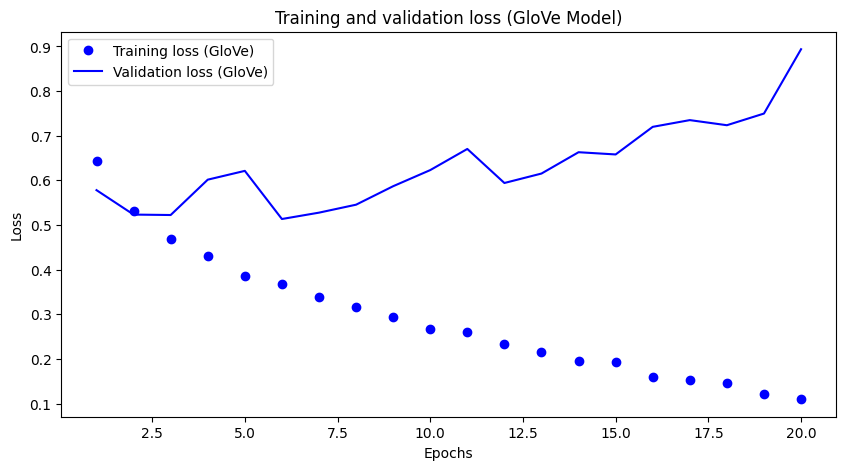

In [57]:
import matplotlib.pyplot as plt

history_glove_dict = history_glove.history

acc_glove = history_glove_dict['binary_accuracy']
val_acc_glove = history_glove_dict['val_binary_accuracy']
loss_glove = history_glove_dict['loss']
val_loss_glove = history_glove_dict['val_loss']

epochs = range(1, len(acc_glove) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, loss_glove, 'bo', label='Training loss (GloVe)')
plt.plot(epochs, val_loss_glove, 'b', label='Validation loss (GloVe)')
plt.title('Training and validation loss (GloVe Model)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

<Figure size 640x480 with 0 Axes>

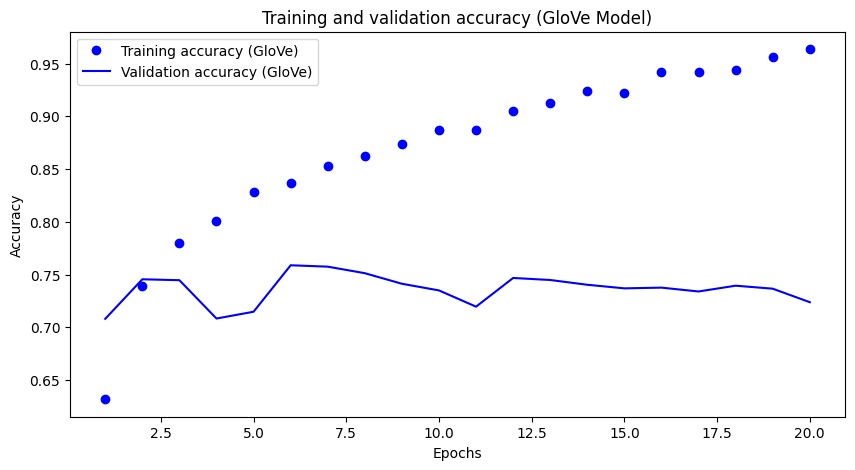

In [58]:
plt.clf()   # clear figure

plt.figure(figsize=(10, 5))
plt.plot(epochs, acc_glove, 'bo', label='Training accuracy (GloVe)')
plt.plot(epochs, val_acc_glove, 'b', label='Validation accuracy (GloVe)')
plt.title('Training and validation accuracy (GloVe Model)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

---

## Comparison of All Models: Bag-of-Words vs. Keras Embedding vs. Word2Vec vs. GloVe

Now, let's bring all our models together and visually compare their performance on the validation set. We will plot the validation loss and accuracy for:

1.  **Bag-of-Words (BoW)**: Uses a sparse representation of word counts.
2.  **Keras-learned Embedding**: Learns dense word representations from scratch.
3.  **Word2Vec Embedding**: Uses pre-trained static word embeddings from `gensim`.
4.  **GloVe Embedding**: Uses pre-trained static word embeddings from the GloVe corpus.

This comparison will help us understand the strengths and weaknesses of each approach for this specific sentiment analysis task.

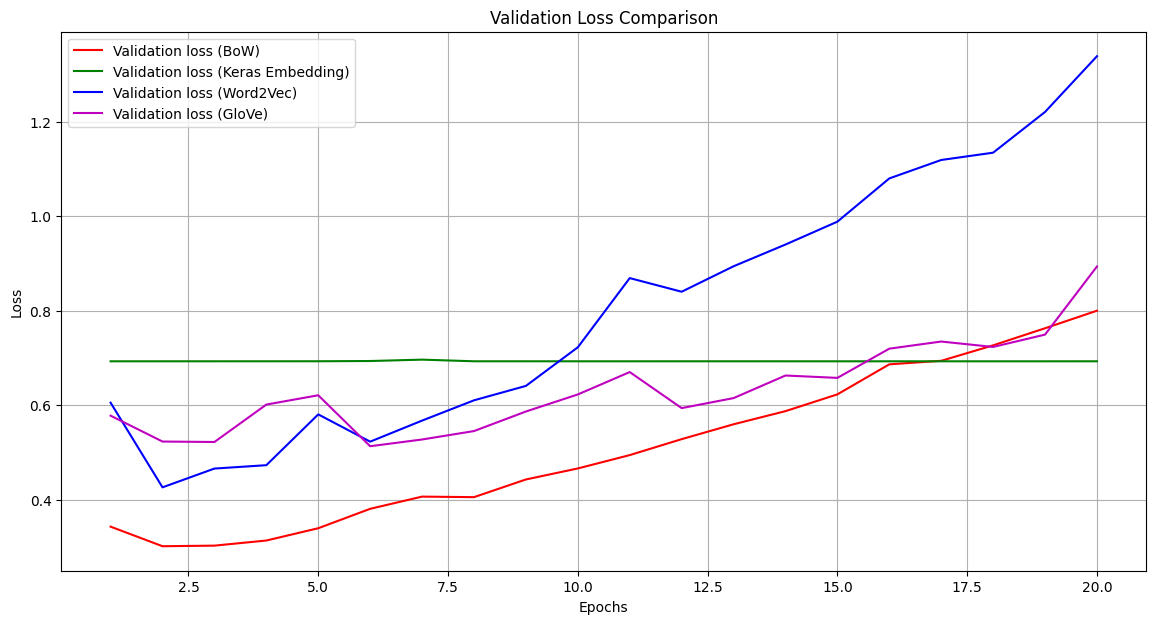

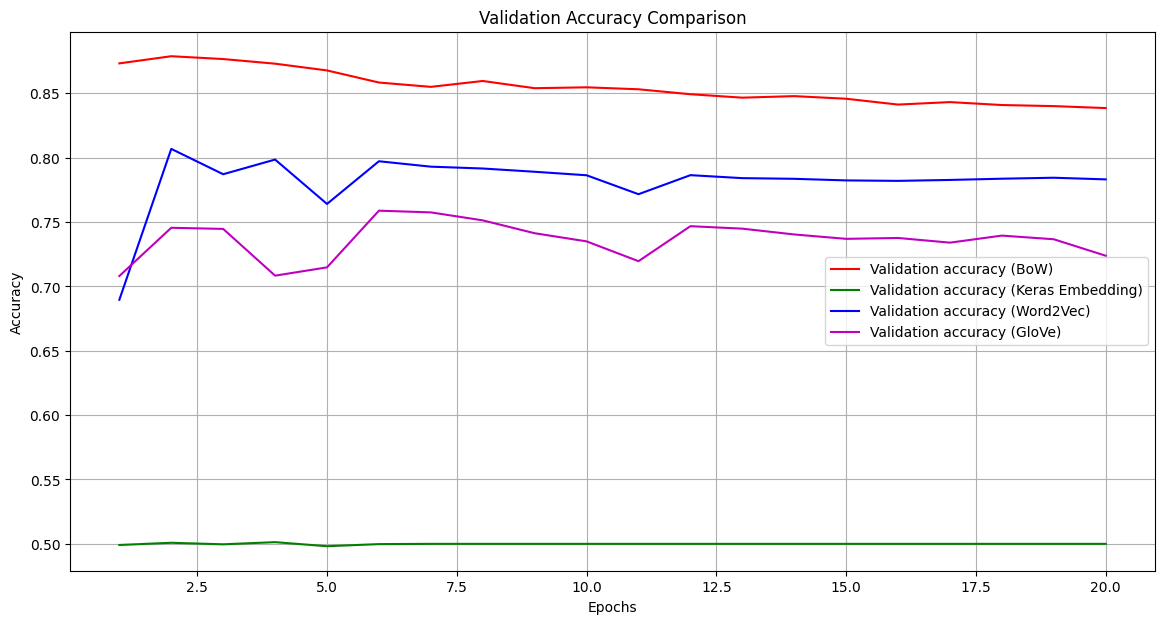


--- Final Validation Metrics ---
Bag-of-Words: Loss = 0.8002, Accuracy = 0.8386
Keras Embedding: Loss = 0.6932, Accuracy = 0.5000
Word2Vec Embedding: Loss = 1.3387, Accuracy = 0.7832
GloVe Embedding: Loss = 0.8937, Accuracy = 0.7238


In [59]:
import matplotlib.pyplot as plt

# Extract data for BoW model
history_bow_dict = history.history
val_loss_bow = history_bow_dict['val_loss']
val_acc_bow = history_bow_dict['val_binary_accuracy']
epochs_bow = range(1, len(val_acc_bow) + 1)

# Extract data for Keras Embedding model
val_loss_embedding = history_embedding_dict['val_loss']
val_acc_embedding = history_embedding_dict['val_binary_accuracy']
epochs_embedding = range(1, len(val_acc_embedding) + 1)

# Extract data for Word2Vec Embedding model
val_loss_w2v = history_w2v_dict['val_loss']
val_acc_w2v = history_w2v_dict['val_binary_accuracy']
epochs_w2v = range(1, len(val_acc_w2v) + 1)

# Extract data for GloVe Embedding model
val_loss_glove = history_glove_dict['val_loss']
val_acc_glove = history_glove_dict['val_binary_accuracy']
epochs_glove = range(1, len(val_acc_glove) + 1)

# Plotting Validation Loss
plt.figure(figsize=(14, 7))
plt.plot(epochs_bow, val_loss_bow, 'r', label='Validation loss (BoW)')
plt.plot(epochs_embedding, val_loss_embedding, 'g', label='Validation loss (Keras Embedding)')
plt.plot(epochs_w2v, val_loss_w2v, 'b', label='Validation loss (Word2Vec)')
plt.plot(epochs_glove, val_loss_glove, 'm', label='Validation loss (GloVe)')
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Plotting Validation Accuracy
plt.figure(figsize=(14, 7))
plt.plot(epochs_bow, val_acc_bow, 'r', label='Validation accuracy (BoW)')
plt.plot(epochs_embedding, val_acc_embedding, 'g', label='Validation accuracy (Keras Embedding)')
plt.plot(epochs_w2v, val_acc_w2v, 'b', label='Validation accuracy (Word2Vec)')
plt.plot(epochs_glove, val_acc_glove, 'm', label='Validation accuracy (GloVe)')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Print final metrics for quick comparison
print("\n--- Final Validation Metrics ---")
print(f"Bag-of-Words: Loss = {val_loss_bow[-1]:.4f}, Accuracy = {val_acc_bow[-1]:.4f}")
print(f"Keras Embedding: Loss = {val_loss_embedding[-1]:.4f}, Accuracy = {val_acc_embedding[-1]:.4f}")
print(f"Word2Vec Embedding: Loss = {val_loss_w2v[-1]:.4f}, Accuracy = {val_acc_w2v[-1]:.4f}")
print(f"GloVe Embedding: Loss = {val_loss_glove[-1]:.4f}, Accuracy = {val_acc_glove[-1]:.4f}")